# Model Training


*   CNN from scratch




### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')
import os
import cv2
import hashlib
import random
from collections import Counter
from google.colab import drive
np.random.seed(42)
import torch                         # Import PyTorch main library for tensor operations and deep learning
import torch.nn as nn                # Import neural network module and alias it as nn
import torch.optim as optim          # Import optimization algorithms (e.g., SGD, Adam)
from torch.utils.data import DataLoader, TensorDataset   # Import tools for batching and handling datasets
import seaborn as sns                # Import Seaborn library for statistical/data visualization
from sklearn.metrics import confusion_matrix, classification_report  # Import evaluation metrics for classification models
torch.manual_seed(42)                # Set PyTorch random seed for reproducible results

### Loading Data

In [ ]:
drive.mount('/drive')
CSV_PATH = "/drive/MyDrive/ML/A_Z Handwritten Data.csv"

# Confirm full file
size_mb = os.path.getsize(CSV_PATH) / 1e6
print(f"File size: {size_mb:.1f} MB")

Mounted at /drive
File size: 698.9 MB


In [ ]:
SAVE_DIR = "/drive/MyDrive/ML/processed_data/"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
data = np.load(SAVE_DIR + "az_dataset_full.npz")
images = data["images"]
labels = data["labels"]

In [ ]:
from google.colab import drive
drive.mount('/drive', force_remount=True)

SAVE_DIR = "/drive/MyDrive/ML/processed_data/"
save_path = SAVE_DIR + "az_dataset_Final.npz"

data = np.load(save_path)
X_final = data["X_final"]
y_final = data["y_final"]

print(f"X_final : {X_final.shape}, dtype: {X_final.dtype}")
print(f"y_final : {y_final.shape}, dtype: {y_final.dtype}")

Mounted at /drive


Exception ignored in: <function NpzFile.__del__ at 0x7ad79c79d1c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected


X_final : (104000, 28, 28, 1), dtype: float32
y_final : (104000,), dtype: int64


In [ ]:
data = np.load(SAVE_DIR + "az_dataset_splits.npz")

X_val   = data["X_val"]
X_test  = data["X_test"]
y_val   = data["y_val"]
y_test  = data["y_test"]

In [ ]:
NUM_CLASSES = len(np.unique(y_final))
print(f"Number of classes: {NUM_CLASSES}")
print(f"Augmented training set size: {len(X_final):,}")
print(f"Validation set size: {len(X_val):,}")
print(f"Test set size: {len(X_test):,}")

Number of classes: 26
Augmented training set size: 104,000
Validation set size: 30,164
Test set size: 30,165


# **CNN**

In [ ]:
def numpy_to_tensor(images, labels):
    images_t = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
    labels_t = torch.tensor(labels, dtype=torch.long)
    return images_t, labels_t

In [ ]:
BATCH_SIZE  = 128

In [ ]:
X_train_t, y_train_t = numpy_to_tensor(X_final, y_final)
X_val_t,   y_val_t   = numpy_to_tensor(X_val,   y_val)
X_test_t,  y_test_t  = numpy_to_tensor(X_test,  y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train tensor shape : {X_train_t.shape}")
print(f"Val tensor shape   : {X_val_t.shape}")
print(f"Test tensor shape  : {X_test_t.shape}")
print(f"Label dtype        : {y_train_t.dtype}")

Train tensor shape : torch.Size([104000, 1, 28, 28])
Val tensor shape   : torch.Size([30164, 1, 28, 28])
Test tensor shape  : torch.Size([30165, 1, 28, 28])
Label dtype        : torch.int64


In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=26):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # → (32, 14, 14)

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # → (64, 7, 7)

            # Block 3 — extra depth, no pooling to keep spatial info
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
model_v2  = ImprovedCNN(NUM_CLASSES)

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(model_v2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

In [ ]:
EPOCHS      = 40
PATIENCE    = 7
save_path   = "/drive/MyDrive/ML/best_model_v2.pth"

best_val_loss = float('inf')
no_improve    = 0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

In [ ]:
if os.path.exists(save_path):
    print("Trained model already exists. Loading saved model...")
    model_v2.load_state_dict(torch.load(save_path))
    model_v2.eval()

else:
    print("No saved model found. Starting training...")

    for epoch in range(EPOCHS):

        # TRAIN
        model_v2.train()
        train_loss = train_correct = train_total = 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model_v2(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total += labels.size(0)

        avg_train_loss = train_loss / train_total
        avg_train_acc = 100 * train_correct / train_total

        # VALIDATION
        model_v2.eval()
        val_loss = val_correct = val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model_v2(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / val_total
        avg_val_acc = 100 * val_correct / val_total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(avg_train_acc)
        val_accs.append(avg_val_acc)

        scheduler.step(avg_val_loss)

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | "
            f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.2f}%"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            no_improve = 0
            torch.save(model_v2.state_dict(), save_path)
            print(f"Best model saved to {save_path}")
        else:
            no_improve += 1
            print(f"No improvement: {no_improve}/{PATIENCE}")
            if no_improve >= PATIENCE:
                print("Early stopping triggered")
                break

Trained model already exists. Loading saved model...


── Plot curves ─────────────────────────────────────────

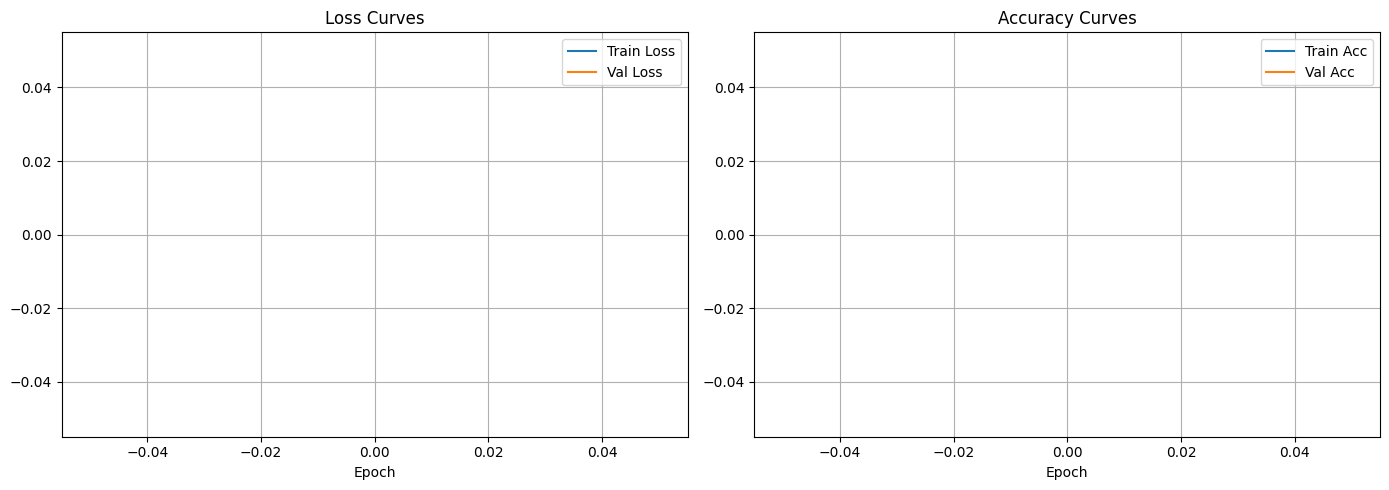

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs,   label='Val Acc')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

── Final test accuracy ─────────────────────────────────

In [ ]:
model_v2.load_state_dict(torch.load(save_path))
model_v2.eval()

correct = total = 0
with torch.no_grad():
    for images, labels in test_loader:
        preds = model_v2(images).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"\nFinal Test Accuracy: {100 * correct / total:.2f}%")


Final Test Accuracy: 98.69%


In [ ]:
model_v2.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        preds = model_v2(images).argmax(1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
      target_names=[chr(i) for i in range(ord('A'), ord('Z')+1)]))

              precision    recall  f1-score   support

           A       0.98      0.99      0.99      1152
           B       0.99      0.99      0.99       720
           C       0.99      0.99      0.99      1826
           D       0.93      0.97      0.95       814
           E       0.99      0.98      0.99       906
           F       0.97      1.00      0.98       172
           G       0.95      0.98      0.97       481
           H       0.97      0.97      0.97       596
           I       0.96      1.00      0.98       159
           J       0.98      0.97      0.98       689
           K       0.99      0.98      0.99       473
           L       0.99      0.98      0.99       934
           M       0.99      1.00      0.99      1556
           N       0.99      0.98      0.99      1487
           O       0.99      0.99      0.99      4396
           P       1.00      0.98      0.99      1513
           Q       0.94      0.99      0.97       492
           R       0.99    

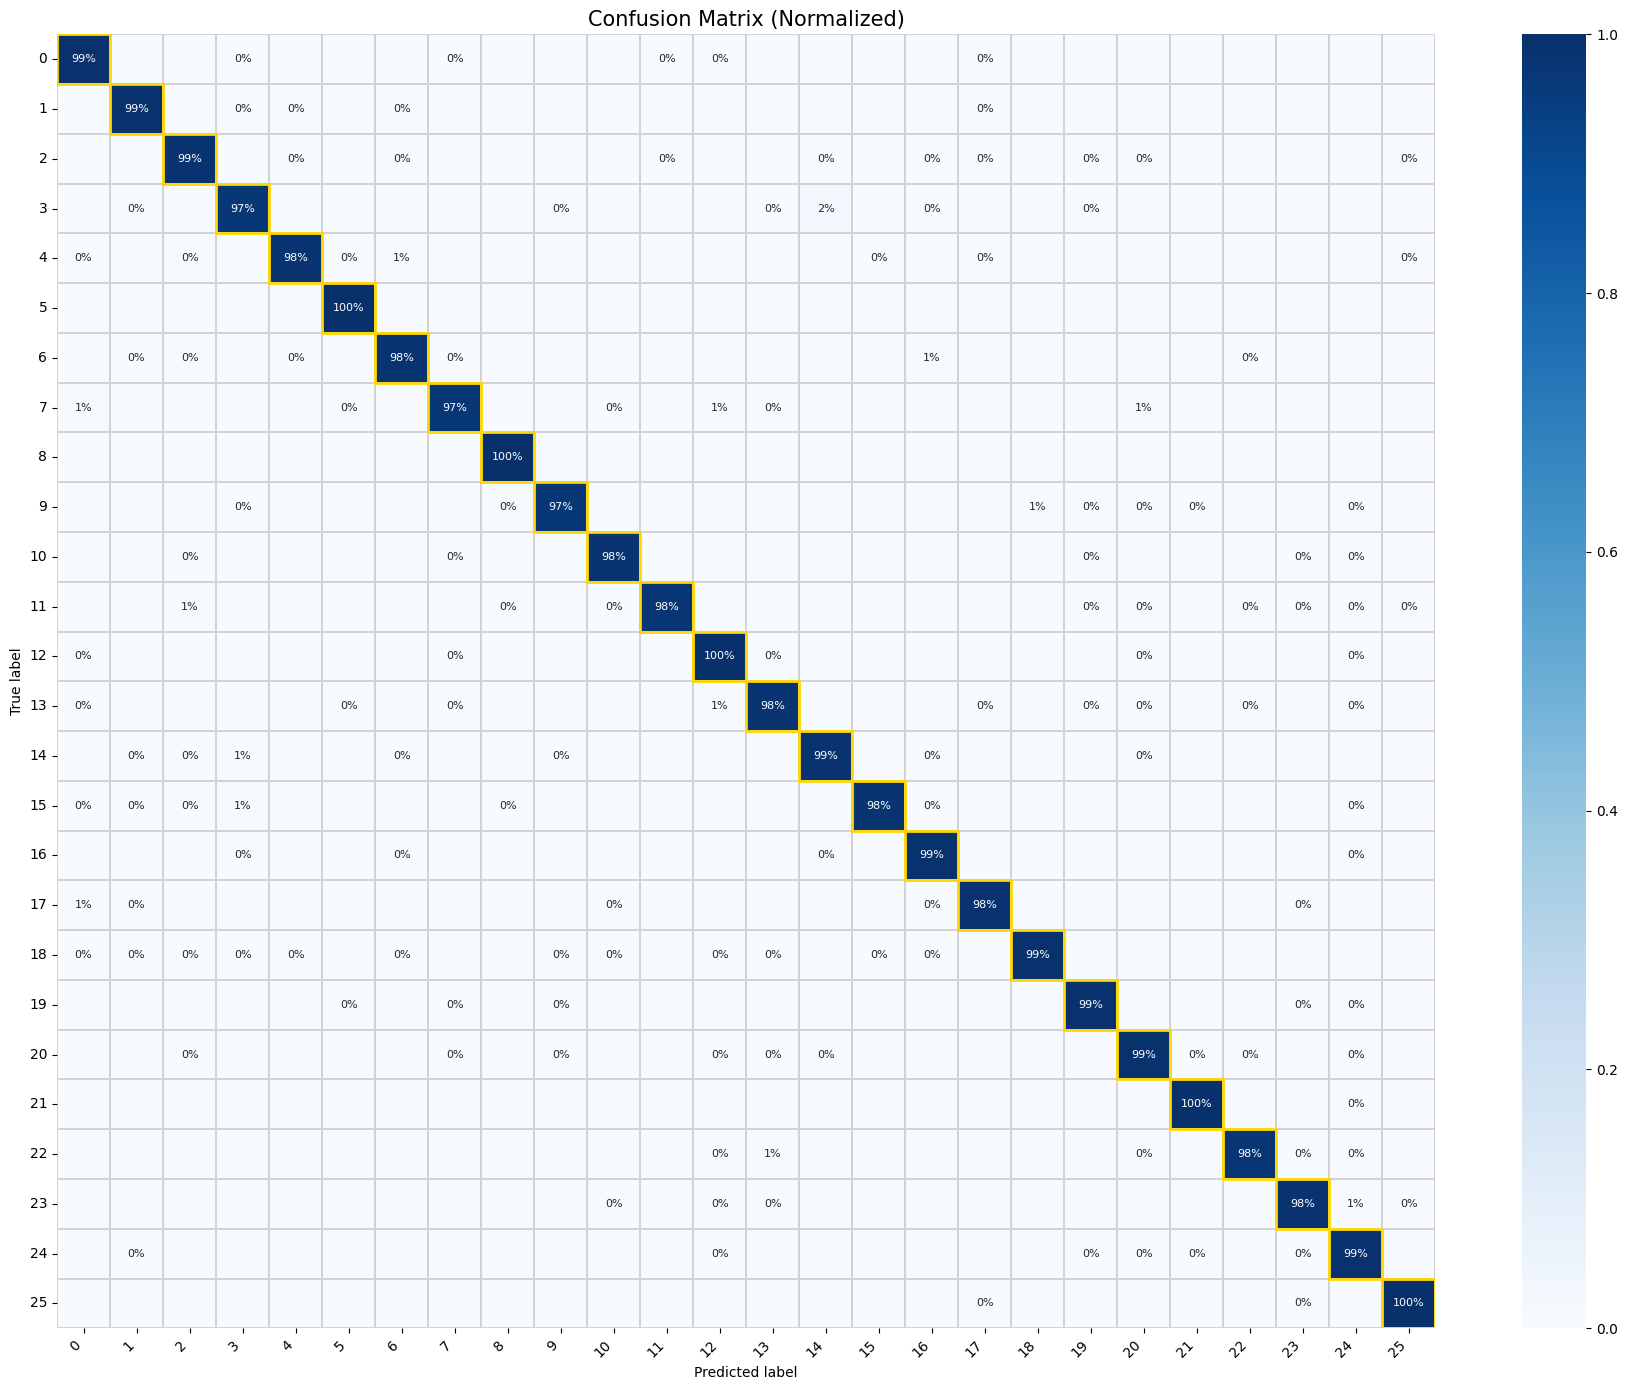

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
n_classes = cm.shape[0]

# Normalize
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Percentage annotations
annot = (cm_norm * 100).round(0).astype(int).astype(str)
annot = np.where(cm > 0, annot + "%", "")

plt.figure(figsize=(18, 14))

ax = sns.heatmap(
    cm_norm,
    annot=annot,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    linecolor="lightgray",
    annot_kws={"size": 8}
)

# Highlight diagonal
for i in range(n_classes):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="gold", lw=2))

plt.title("Confusion Matrix (Normalized)", fontsize=15)
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

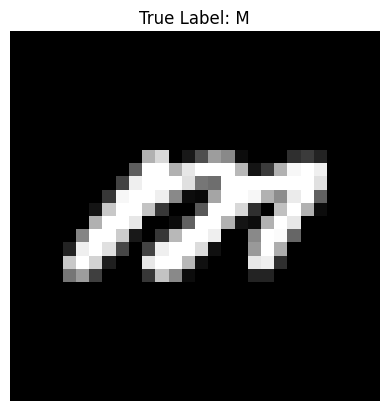

Predicted Class: M


In [ ]:
# Inference on one image
sample_img = X_test_t[10]
sample_label = y_test_t[10].item()

plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title(f"True Label: {chr(sample_label + ord('A'))}")
plt.axis('off')
plt.show()

sample_tensor = sample_img.unsqueeze(0)
with torch.no_grad():
    output = model_v2(sample_tensor)
    predicted_class = output.argmax(1).item()
    print(f"Predicted Class: {chr(predicted_class + ord('A'))}")

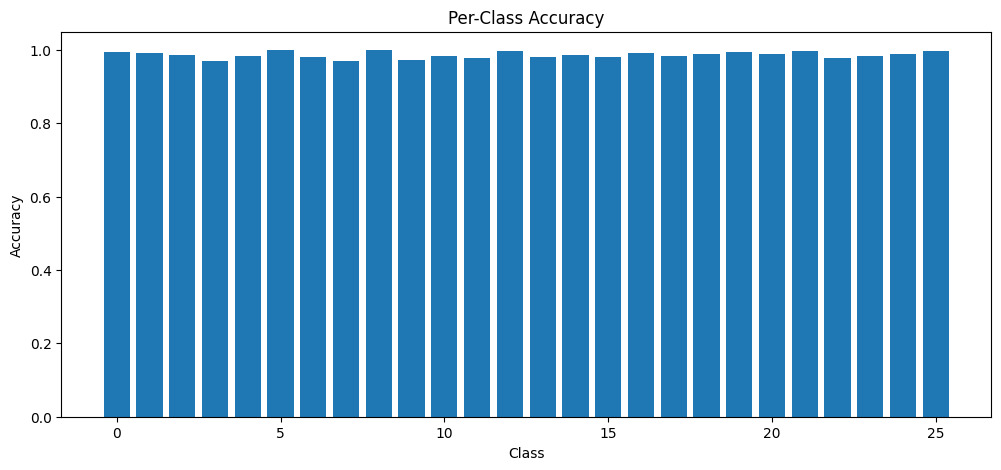

In [ ]:
#Plots
cm = confusion_matrix(all_labels, all_preds)
acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(12,5))
plt.bar(range(len(acc)), acc)
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()
